In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import scienceplots 
import numpy as np

plt.style.use(["science","notebook", "grid"])

from funciones import joint_simulation, get_molecules

from ase.visualize import view
from ase.io import read, write
from ase.geometry.analysis import get_rdf # < ----- Dio muchos problemas
from rdfpy import rdf
import pandas as pd
from scipy.interpolate import Akima1DInterpolator

# Completed simulation

Untill today

In [3]:
md = joint_simulation(folders=["./outputs_1","./outputs_2", "./outputs_3"])


Processing folder: ./outputs_1
Processing file: pw.out.27896 ---- 217 frames
Processing file: pw.out.27972 ---- 177 frames
Processing file: pw.out.28006 ---- 228 frames
Processing file: pw.out.28046 ---- 201 frames
Processing file: pw.out.28099 ---- 169 frames
Total frames on ./outputs_1 folder: 992

Processing folder: ./outputs_2
Processing file: pw.out.28895 ---- 182 frames
Processing file: pw.out.28984 ---- 183 frames
Processing file: pw.out.29046 ---- 169 frames
Processing file: pw.out.29139 ---- 178 frames
Processing file: pw.out.29374 ---- 186 frames
Processing file: pw.out.29624 ---- 185 frames
Processing file: pw.out.29799 ---- 195 frames
Processing file: pw.out.29937 ---- 196 frames
Processing file: pw.out.30033 ---- 200 frames
Processing file: pw.out.30117 ---- 209 frames
Total frames on ./outputs_2 folder: 2875

Processing folder: ./outputs_3
Processing file: pw.out.119 ---- 208 frames
Processing file: pw.out.120 ---- 200 frames
Processing file: pw.out.121 ---- 185 frames
P

In [4]:
energies = np.zeros(len(md))
temperatures = np.zeros(len(md))
for i in range(len(md)):
	energies[i] = md[i].get_potential_energy()
	temperatures[i] = md[i].info['temperature']

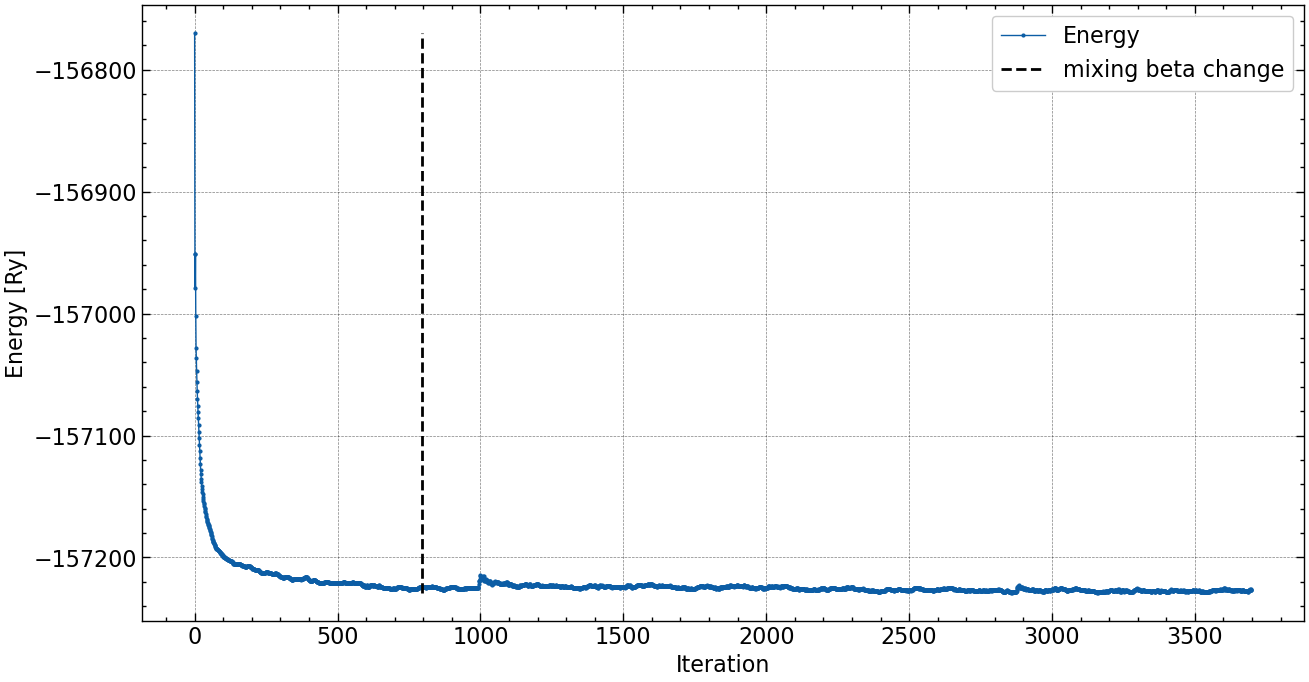

In [5]:
fig, ax = plt.subplots(1,1, figsize=(15,8))
ax.plot(energies, 'o-', ms = 2, linewidth = 1, label = 'Energy')
ax.vlines(x=794, ymax=np.max(energies), ymin=np.min(energies), label ="mixing beta change", color = 'black', linestyles='--')
ax.set_ylabel("Energy [Ry]")
ax.set_xlabel("Iteration")
ax.legend()
fig.savefig("energia.png")

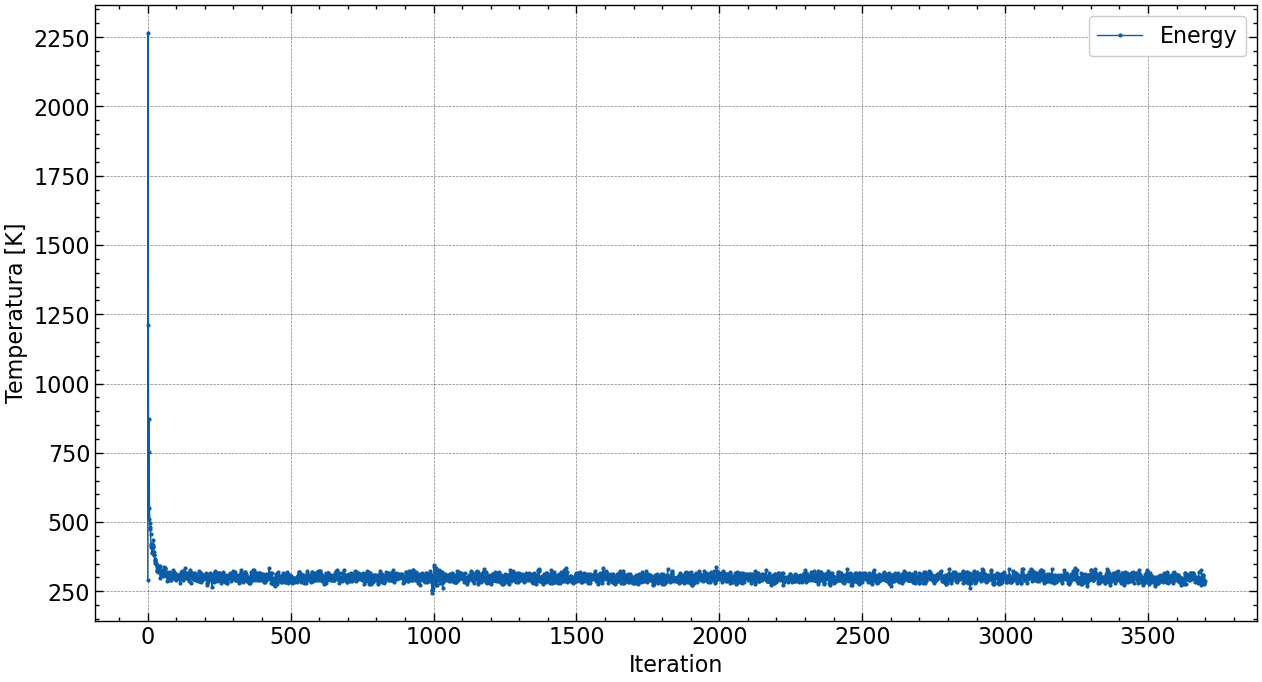

In [6]:
fig, ax = plt.subplots(1,1, figsize=(15,8))
ax.plot(temperatures, 'o-', ms = 2, linewidth = 1, label = 'Energy')
#ax.vlines(x=794, ymax=np.max(energies), ymin=np.min(energies), label ="mixing beta change", color = 'black', linestyles='--')
ax.set_ylabel("Temperatura [K]")
ax.set_xlabel("Iteration")
ax.legend()
fig.savefig("temperatura.png")

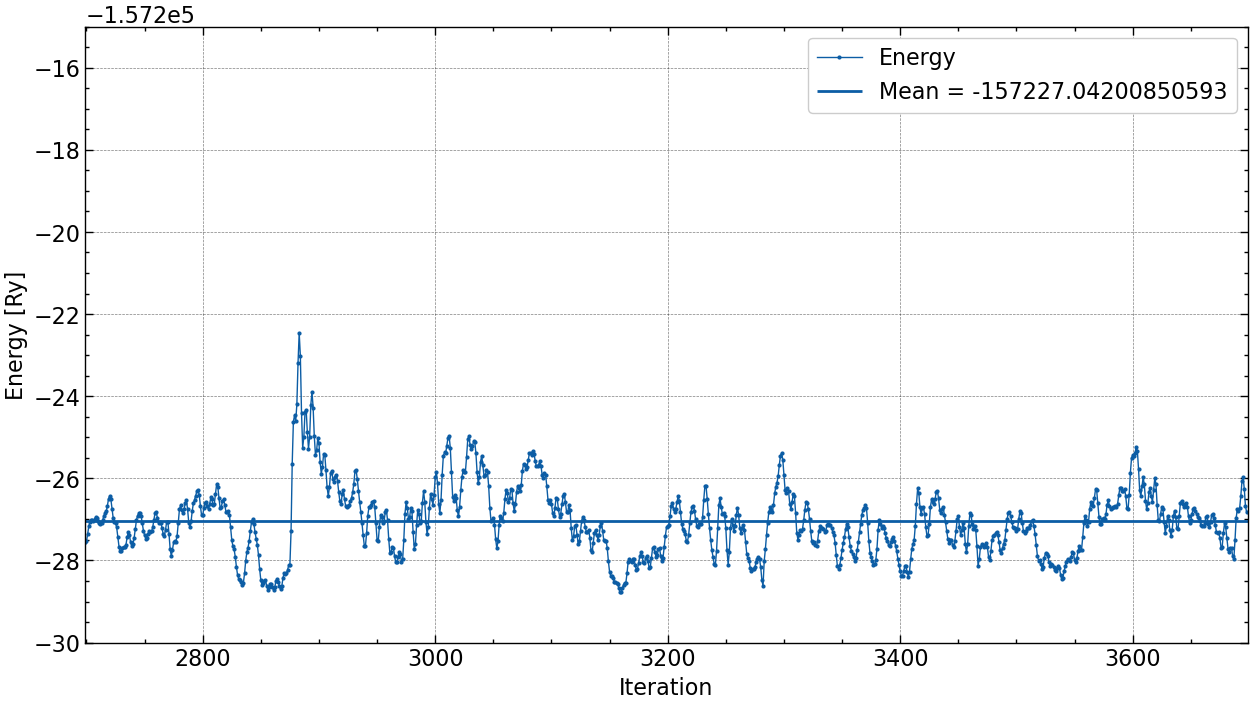

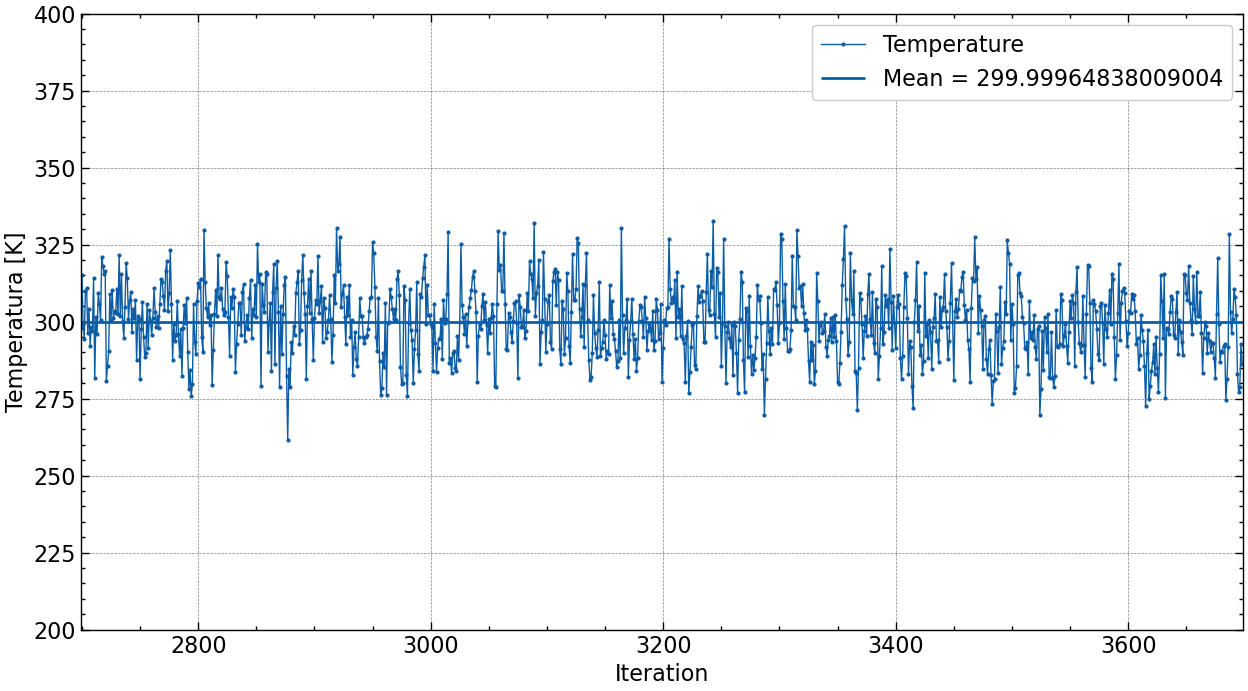

In [7]:
# === PRIMERA GRAFICA: Energía ===

fig, ax = plt.subplots(1,1, figsize=(15,8))
ax.plot(energies, 'o-', ms=2, linewidth=1, label='Energy')
#ax.vlines(x=794, ymax=np.max(energies), ymin=np.min(energies),label="mixing beta change", color='black', linestyles='--')

# ZOOM en las ultimas 1000 iteraciones
N = len(energies)
ax.set_xlim(max(0, N-1000), N)
ax.set_ylim(ymax=-157215, ymin= -157230)

ax.hlines(y = np.mean(energies[-1000:]), xmin=0,xmax=4000, label= f"Mean = {np.mean(energies[-1000:])}")

ax.set_ylabel("Energy [Ry]")
ax.set_xlabel("Iteration")
ax.legend()
fig.savefig("energia_zoom.png")


# === SEGUNDA GRAFICA: Temperatura ===

fig, ax = plt.subplots(1,1, figsize=(15,8))
ax.plot(temperatures, 'o-', ms=2, linewidth=1, label='Temperature')

# ZOOM en las ultimas 1000 iteraciones
N2 = len(temperatures)
ax.set_xlim(max(0, N2-1000), N2)
ax.set_ylim(200,400)
ax.hlines(y = np.mean(temperatures[-1000:]), xmin=0,xmax=4000, label= f"Mean = {np.mean(temperatures[-1000:])}")

ax.set_ylabel("Temperatura [K]")
ax.set_xlabel("Iteration")
ax.legend()
fig.savefig("temperatura_zoom.png")


In [8]:
md[0].symbols.indices()['Al']

array([ 3,  7, 11, 15, 19, 23, 27, 31, 35, 39, 43, 47, 51])

In [9]:
electrolyte = get_molecules(['molecules/alcl3_opt.xyz','molecules/1-Ethyl-3-methylimidazolium_chloride_opt.xyz'], 'inputs/pw_inicial.in')
len(electrolyte) # if it is 30, all is ok

30

In [10]:
electrolyte_idx = np.zeros(len(electrolyte), dtype=object)

for i in range(len(electrolyte)):
	electrolyte_idx[i] = np.zeros(len(electrolyte[i].atomos), dtype=int)
	print(f"Molecule {i}: {electrolyte[i]}")
	for j in range(len(electrolyte[i].atomos)):
		print(f"  Atom {j} - {electrolyte[i].atomos[j].simbolo}: {electrolyte[i].atomos[j].idx}")
		electrolyte_idx[i][j] = electrolyte[i].atomos[j].idx
electrolyte_idx_conca = np.concatenate(electrolyte_idx)

# indixes: 
# 0 - 12 : AlCl3
# 13 - 29 : EMImCl
# Check output

Molecule 0: <funciones.Molecula object at 0x7c2954f070e0>
  Atom 0 - Cl: 0
  Atom 1 - Cl: 1
  Atom 2 - Cl: 2
  Atom 3 - Al: 3
Molecule 1: <funciones.Molecula object at 0x7c2951cb1e50>
  Atom 0 - Cl: 4
  Atom 1 - Cl: 5
  Atom 2 - Cl: 6
  Atom 3 - Al: 7
Molecule 2: <funciones.Molecula object at 0x7c2951cb1f90>
  Atom 0 - Cl: 8
  Atom 1 - Cl: 9
  Atom 2 - Cl: 10
  Atom 3 - Al: 11
Molecule 3: <funciones.Molecula object at 0x7c295936d480>
  Atom 0 - Cl: 12
  Atom 1 - Cl: 13
  Atom 2 - Cl: 14
  Atom 3 - Al: 15
Molecule 4: <funciones.Molecula object at 0x7c295936ce90>
  Atom 0 - Cl: 16
  Atom 1 - Cl: 17
  Atom 2 - Cl: 18
  Atom 3 - Al: 19
Molecule 5: <funciones.Molecula object at 0x7c295a22e210>
  Atom 0 - Cl: 20
  Atom 1 - Cl: 21
  Atom 2 - Cl: 22
  Atom 3 - Al: 23
Molecule 6: <funciones.Molecula object at 0x7c295803d6a0>
  Atom 0 - Cl: 24
  Atom 1 - Cl: 25
  Atom 2 - Cl: 26
  Atom 3 - Al: 27
Molecule 7: <funciones.Molecula object at 0x7c295803d8c0>
  Atom 0 - Cl: 28
  Atom 1 - Cl: 29
  Atom

In [41]:
nanoscroll_idx = np.arange(electrolyte_idx_conca[-1]+1,len(md[0]),1, dtype=int)
#nanoscroll_idx

In [42]:
carbons_electrolyte = np.concatenate([mol_idx[2:8] for mol_idx in electrolyte_idx[13:]
])
#carbons_electrolyte

In [43]:
pwin = read("inputs/pw_inicial.in", format="espresso-in")

constraints = getattr(pwin, 'constraints', None)
constraints[0].index # Indices de los atomos que estan fijos en la simulacion, en este caso los carbonos del nanoscroll

array([457, 458, 459, 460, 461, 462, 463, 464, 465, 466, 467, 468, 469,
       470, 471, 472, 473, 474, 475, 476, 477, 478, 479, 480, 481, 482,
       483, 484, 485, 486, 487, 488, 489, 490, 491, 492, 493, 494, 495,
       496, 497, 498, 499, 500, 501, 502, 503, 504, 505, 506, 507, 508,
       509, 510, 511, 512, 513, 514, 515, 516, 517, 518, 519])

In [44]:
mask = ~np.isin(nanoscroll_idx,constraints[0].index)
mask

nanoscroll_idx_not_fixed = nanoscroll_idx[mask]
nanoscroll_idx_not_fixed

array([392, 393, 394, 395, 396, 397, 398, 399, 400, 401, 402, 403, 404,
       405, 406, 407, 408, 409, 410, 411, 412, 413, 414, 415, 416, 417,
       418, 419, 420, 421, 422, 423, 424, 425, 426, 427, 428, 429, 430,
       431, 432, 433, 434, 435, 436, 437, 438, 439, 440, 441, 442, 443,
       444, 445, 446, 447, 448, 449, 450, 451, 452, 453, 454, 455, 456,
       520, 521, 522, 523, 524, 525, 526, 527, 528, 529, 530, 531, 532,
       533, 534, 535, 536, 537, 538, 539, 540, 541, 542, 543, 544, 545,
       546, 547, 548, 549, 550, 551, 552, 553, 554, 555, 556, 557, 558,
       559, 560, 561, 562, 563, 564, 565, 566, 567, 568, 569, 570, 571,
       572, 573, 574, 575, 576, 577, 578, 579, 580, 581, 582, 583])

In [45]:
# Obteniendo los indices de los diferentes atomos que forman el electrolito
# Se puede usar tambien:
# md[0].symbols.indices['Al']
Al_electrolyte = np.concatenate([np.array([mol_idx[3]]) for mol_idx in electrolyte_idx[:13]])
N_electrolyte = np.concatenate([mol_idx[0:2] for mol_idx in electrolyte_idx[13:]])
Cl_electrolyte = np.concatenate([np.concatenate([mol_idx[0:3] for mol_idx in electrolyte_idx[:13]]), 
								np.concatenate([np.array([mol_idx[-1]]) for mol_idx in electrolyte_idx[13:]])])

In [46]:
# Se unen los indices de atomos de interes del electrolito con los indices de los carbonos del nanoscroll
all_C = np.concatenate([carbons_electrolyte,nanoscroll_idx])
C_plus_Al = np.concatenate([Al_electrolyte,nanoscroll_idx])
C_plus_N = np.concatenate([N_electrolyte,nanoscroll_idx])
C_plus_Cl = np.concatenate([Cl_electrolyte, nanoscroll_idx])
C_not_fixed_Cl = np.concatenate([Cl_electrolyte, nanoscroll_idx_not_fixed])

Generando un .csv para cada conjunto de atomos de interés

In [47]:
conjunto_de_interes = [C_plus_Al, C_plus_N, C_plus_Cl, C_not_fixed_Cl]
labels = ['C_plus_Al', 'C_plus_N', 'C_plus_Cl', 'C_not_fixed_Cl']

for i, conjunto in enumerate(conjunto_de_interes):

    data = {}
    k = 150

    for j in range(-150, 0):

        rdf_vals, r_vals = rdf(
            md[j][conjunto].positions,
            dr=0.05
        )

        data[f"r{k}"]   = pd.Series(r_vals)
        data[f"rdf{k}"] = pd.Series(rdf_vals)

        k -= 1

    df = pd.DataFrame(data)

    filename = f"rdf_{labels[i]}.csv"
    df.to_csv(f"rdf/{filename}", index=False)

    print(f"Archivo generado: {filename}")


/home/hernan-barquero/anaconda3/envs/general/lib/python3.13/site-packages/rdfpy/rdfpy.py:27: RuntimeWarning: invalid value encountered in scalar divide
  g_r_partial[r_idx] /= n_valid*shell_vol*rho
/home/hernan-barquero/anaconda3/envs/general/lib/python3.13/site-packages/rdfpy/rdfpy.py:27: RuntimeWarning: invalid value encountered in scalar divide
  g_r_partial[r_idx] /= n_valid*shell_vol*rho
/home/hernan-barquero/anaconda3/envs/general/lib/python3.13/site-packages/rdfpy/rdfpy.py:27: RuntimeWarning: invalid value encountered in scalar divide
  g_r_partial[r_idx] /= n_valid*shell_vol*rho
/home/hernan-barquero/anaconda3/envs/general/lib/python3.13/site-packages/rdfpy/rdfpy.py:27: RuntimeWarning: invalid value encountered in scalar divide
  g_r_partial[r_idx] /= n_valid*shell_vol*rho
/home/hernan-barquero/anaconda3/envs/general/lib/python3.13/site-packages/rdfpy/rdfpy.py:27: RuntimeWarning: invalid value encountered in scalar divide
  g_r_partial[r_idx] /= n_valid*shell_vol*rho
/home/hern

Archivo generado: rdf_C_plus_Al.csv
Archivo generado: rdf_C_plus_N.csv


/home/hernan-barquero/anaconda3/envs/general/lib/python3.13/site-packages/rdfpy/rdfpy.py:27: RuntimeWarning: invalid value encountered in scalar divide
  g_r_partial[r_idx] /= n_valid*shell_vol*rho
/home/hernan-barquero/anaconda3/envs/general/lib/python3.13/site-packages/rdfpy/rdfpy.py:27: RuntimeWarning: invalid value encountered in scalar divide
  g_r_partial[r_idx] /= n_valid*shell_vol*rho
/home/hernan-barquero/anaconda3/envs/general/lib/python3.13/site-packages/rdfpy/rdfpy.py:27: RuntimeWarning: invalid value encountered in scalar divide
  g_r_partial[r_idx] /= n_valid*shell_vol*rho
/home/hernan-barquero/anaconda3/envs/general/lib/python3.13/site-packages/rdfpy/rdfpy.py:27: RuntimeWarning: invalid value encountered in scalar divide
  g_r_partial[r_idx] /= n_valid*shell_vol*rho
/home/hernan-barquero/anaconda3/envs/general/lib/python3.13/site-packages/rdfpy/rdfpy.py:27: RuntimeWarning: invalid value encountered in scalar divide
  g_r_partial[r_idx] /= n_valid*shell_vol*rho
/home/hern

Archivo generado: rdf_C_plus_Cl.csv


/home/hernan-barquero/anaconda3/envs/general/lib/python3.13/site-packages/rdfpy/rdfpy.py:27: RuntimeWarning: invalid value encountered in scalar divide
  g_r_partial[r_idx] /= n_valid*shell_vol*rho
/home/hernan-barquero/anaconda3/envs/general/lib/python3.13/site-packages/rdfpy/rdfpy.py:27: RuntimeWarning: invalid value encountered in scalar divide
  g_r_partial[r_idx] /= n_valid*shell_vol*rho
/home/hernan-barquero/anaconda3/envs/general/lib/python3.13/site-packages/rdfpy/rdfpy.py:27: RuntimeWarning: invalid value encountered in scalar divide
  g_r_partial[r_idx] /= n_valid*shell_vol*rho
/home/hernan-barquero/anaconda3/envs/general/lib/python3.13/site-packages/rdfpy/rdfpy.py:27: RuntimeWarning: invalid value encountered in scalar divide
  g_r_partial[r_idx] /= n_valid*shell_vol*rho
/home/hernan-barquero/anaconda3/envs/general/lib/python3.13/site-packages/rdfpy/rdfpy.py:27: RuntimeWarning: invalid value encountered in scalar divide
  g_r_partial[r_idx] /= n_valid*shell_vol*rho
/home/hern

Archivo generado: rdf_C_not_fixed_Cl.csv


Ahora hay que interpolar los resultados de cada conjunto de atomos, de modo que se genere una malla común y de esa forma realizar un posterior promedio de los resultados

In [48]:
data_Al = pd.read_csv("rdf/rdf_C_plus_Al.csv")
data_N = pd.read_csv("rdf/rdf_C_plus_N.csv")
data_Cl = pd.read_csv("rdf/rdf_C_plus_Cl.csv")
data_Cl_not_fixed = pd.read_csv("rdf/rdf_C_not_fixed_Cl.csv")

In [49]:
df = [data_Al,data_N,data_Cl, data_Cl_not_fixed]

r_max_list = []

for i in range(len(df)):
	r_columns = [c for c in df[i].columns if c.startswith('r') and not c.startswith('rdf')]

	r_max_list.append(df[i][r_columns].max().min())

print(r_max_list)

[8.350000000000001, 8.0, 9.05, 9.05]


In [50]:
r_Al = np.linspace(0.0, r_max_list[0], num=1000)
r_N = np.linspace(0.0, r_max_list[1], num=1000)
r_Cl = np.linspace(0.0, r_max_list[2], num=1000)
r_Cl_not_fixed = np.linspace(0.0, r_max_list[3], num=1000)

In [54]:
r_common_list = [r_Al, r_N, r_Cl, r_Cl_not_fixed]
data_list = [data_Al, data_N, data_Cl, data_Cl_not_fixed]



for i in range(0,len(data_list)):
	r_common = r_common_list[i]
	df = data_list[i]

	interp_data = {
						"r": r_common
					}

	for k in range(1, 150 + 1):

		r_col = df[f"r{k}"].to_numpy()
		rdf_col = df[f"rdf{k}"].to_numpy()

		mask = np.isfinite(r_col) & np.isfinite(rdf_col)

		r_k = r_col[mask]
		rdf_k = rdf_col[mask]

		interpolation = Akima1DInterpolator(r_k,rdf_k)
		rdf_interp = interpolation(r_common)

		

		interp_data[f"rdf{k}"] = rdf_interp
	df_interp = pd.DataFrame(interp_data)
	df_interp.to_csv(f"rdf/rdf_interp_{labels[i]}.csv", index=False)
	print(f"Archivo generado: rdf_interp_{labels[i]}.csv")

Archivo generado: rdf_interp_C_plus_Al.csv
Archivo generado: rdf_interp_C_plus_N.csv
Archivo generado: rdf_interp_C_plus_Cl.csv
Archivo generado: rdf_interp_C_not_fixed_Cl.csv


In [55]:
data_C_plus_Al = pd.read_csv("rdf/rdf_interp_C_plus_Al.csv")
data_C_plus_N = pd.read_csv("rdf/rdf_interp_C_plus_N.csv")
data_C_plus_Cl = pd.read_csv("rdf/rdf_interp_C_plus_Cl.csv")
data_C_not_fixed_Cl = pd.read_csv("rdf/rdf_interp_C_not_fixed_Cl.csv")

In [56]:
rdf_Al = data_C_plus_Al.drop(columns=['r']).mean(axis=1)
rdf_N = data_C_plus_N.drop(columns=['r']).mean(axis=1)
rdf_Cl = data_C_plus_Cl.drop(columns=['r']).mean(axis=1)
rdf_Cl_not_fixed = data_C_not_fixed_Cl.drop(columns=['r']).mean(axis=1)

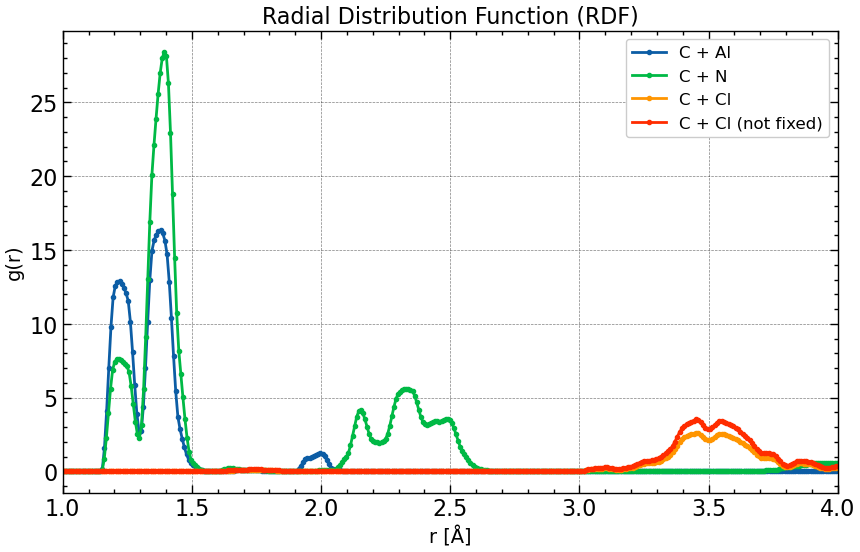

In [57]:
fig, ax = plt.subplots(1,1, figsize=(10,6))
ax.plot(r_Al, rdf_Al,'o-',ms= 3,linewidth=2,  label='C + Al')
ax.plot(r_N, rdf_N,'o-',ms= 3,linewidth =2, label='C + N')
ax.plot(r_Cl, rdf_Cl,'o-',ms= 3,linewidth =2, label='C + Cl')
ax.plot(r_Cl_not_fixed, rdf_Cl_not_fixed,'o-',ms= 3,linewidth =2, label='C + Cl (not fixed)')
ax.set_xlabel("r [Å]", fontsize=14)
ax.set_ylabel("g(r)", fontsize=14)
ax.set_title("Radial Distribution Function (RDF)", fontsize=16)
ax.legend(fontsize=12)
ax.set_xlim(1, 4)
fig.savefig("rdf/rdf_total.png", dpi=300)